# Caso B – Predicción de ventas futuras

## 1. Descripción del problema del negocio

**Problema identificado:** La empresa necesita diagnosticar y predecir con precisión cuánto venderá mensualmente. Esto permitirá optimizar el presupuesto de marketing, ajustar precios de forma estratégica y gestionar el inventario sin caer en sobrestock o desabastecimiento.

**Variable objetivo:** `Ingresos_mensuales` (Tipo: númerica continua).

**Contexto y decisiones:** Al pronosticar los ingresos, la gerencia tomará decisiones proactivas. Por ejemplo, decidirán si deben inyectar capital en campañas publicitarias durante meses de baja estacionalidad o ajustar precios frente a la agresividad de la competencia para mantener la rentabilidad.

## 2. Mapa de selección de algoritmos

Al ser la variable objetivo de tipo númerico continuo, es un problema de tipo **regresión**.

**Objetivo del negocio:** Predecir ingresos mensuales de las tiendas para apoyar marketing, inventario, personal y planificación comercial

Por lo que la familia de algoritmos mas adecuados son los modelos lineales (para obtener y entender la relacion directa de las variables) y de random forest (para capturar patrones complejos).

**Algoritmos candidatos seleccionados y sus limitaciones:**

1. **Regresión Lineal Múltiple**
   - Es el más interpretable por excelencia; cada coeficiente se explica en las mismas unidades del negocio (ej. "cada día de promoción adicional se asocia a X más de ingreso"); rápida de entrenar y de auditar.
   - *Limitaciones:* Asume que las relaciones son siempre líneas rectas y es muy sensible a datos atípicos.

2. **Random Forest Regressor**
   - Captura relaciones no lineales e interacciones automáticamente; robusto a outliers y a variables en distintas escalas; no requiere estandarizar variables; entrega importancia de variables, útil para discusión de negocio.
   - *Limitaciones:* menos interpretable, funciona como una "caja negra"; ademas de un mayor costo computacional; riesgo de sobreajuste si no se limita la profundidad/número de árboles; tiende a extrapolar mal fuera del rango de valores visto en entrenamiento (relevante si una tienda nueva tiene características atípicas).

## 3. Simulación y exploración de datos

### 3.0.1 Importación de librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)

### 3.0.2 Importación de datos

In [3]:
df = pd.read_csv('data/retail_sales_demo_data.csv')

df.shape

(960, 18)

### 3.1 Exploración inicial

In [4]:
display(df.head())

,store_id,year,month,month_index,is_holiday_month,ad_spend,foot_traffic,avg_price,staff_count,store_size_sqft,promo_days,competitors_within_3km,inventory_fill_rate,returns_rate,local_income_index,parking_spaces,store_age_years,monthly_sales
0,1,2023,1,1,0,NaN,3175,28.26,41,29476,4,1,0.930,0.0422,98.3,263,11,2982.20
1,2,2023,1,1,0,NaN,3717,19.86,31,21933,4,3,0.952,0.0415,93.7,171,5,1867.48
2,3,2023,1,1,0,NaN,3747,17.52,44,36259,4,1,0.944,0.0427,97.3,285,8,2141.46
3,4,2023,1,1,0,NaN,5098,25.16,33,21798,6,2,0.965,0.0398,111.4,174,9,3840.05
4,5,2023,1,1,0,NaN,6612,21.03,51,45448,2,2,0.960,0.0420,114.3,389,9,4233.70


In [5]:
df.isnull().sum() # Valida todos los nulos en el dataset

store_id                  0
year                      0
month                     0
month_index               0
is_holiday_month          0
ad_spend                  5
foot_traffic              0
avg_price                 0
staff_count               0
store_size_sqft           0
promo_days                0
competitors_within_3km    0
inventory_fill_rate       0
returns_rate              0
local_income_index        0
parking_spaces            0
store_age_years           0
monthly_sales             0
dtype: int64

In [6]:
df.describe(include="all")

,store_id,year,month,month_index,is_holiday_month,ad_spend,foot_traffic,avg_price,staff_count,store_size_sqft,promo_days,competitors_within_3km,inventory_fill_rate,returns_rate,local_income_index,parking_spaces,store_age_years,monthly_sales
count,960.000000,960.000000,960.000000,960.000000,960.000000,955.000000,960.000000,960.000000,960.000000,960.00000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000
mean,20.500000,2023.500000,6.500000,6.500000,0.166667,13686.633361,5627.037500,22.308365,37.236458,27659.60000,3.176042,3.050000,0.942707,0.037246,103.957500,229.900000,7.700000,3327.192271
std,11.549413,0.500261,3.453852,3.453852,0.372872,5608.992987,32139.040087,3.620570,6.430776,6088.51317,1.094707,1.803021,0.019966,0.005678,9.546459,50.588099,4.390909,1039.404492
min,1.000000,2023.000000,1.000000,1.000000,0.000000,3308.520000,3075.000000,15.220000,20.000000,13486.00000,0.000000,0.000000,0.883000,0.019900,85.400000,126.000000,1.000000,1322.950000
25%,10.750000,2023.000000,3.750000,3.750000,0.000000,9755.870000,3960.500000,19.547500,33.000000,23620.50000,2.000000,2.000000,0.929000,0.033500,96.275000,194.750000,4.750000,2553.870000
50%,20.500000,2023.500000,6.500000,6.500000,0.000000,12728.270000,4370.000000,22.060000,37.000000,28521.50000,3.000000,3.000000,0.943000,0.037300,103.600000,239.000000,8.500000,3150.255000
75%,30.250000,2024.000000,9.250000,9.250000,0.000000,16500.605000,5001.500000,24.662500,41.000000,30500.75000,4.000000,4.250000,0.957000,0.040900,110.475000,254.000000,9.000000,3904.910000
max,40.000000,2024.000000,12.000000,12.000000,1.000000,52692.090000,1000000.000000,32.280000,58.000000,45448.00000,7.000000,8.000000,1.000000,0.055600,126.300000,389.000000,21.000000,8048.290000


In [7]:
display(df.nunique().sort_values())

year                        2
is_holiday_month            2
promo_days                  8
competitors_within_3km      8
month_index                12
month                      12
store_age_years            14
parking_spaces             33
local_income_index         36
staff_count                39
store_id                   40
store_size_sqft            40
inventory_fill_rate       103
returns_rate              248
avg_price                 657
foot_traffic              805
ad_spend                  955
monthly_sales             958
dtype: int64

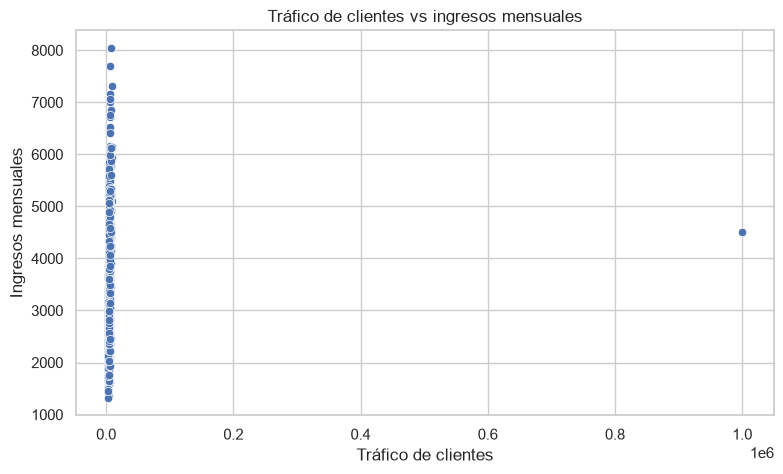

In [8]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x='foot_traffic',
    y='monthly_sales'
)

plt.title('Tráfico de clientes vs ingresos mensuales')
plt.xlabel('Tráfico de clientes')
plt.ylabel('Ingresos mensuales')

plt.show()

### 3.2 Limpieza de datos

Tras validar el dataset, se observa que hay datos faltantes en la columna `ad_spend` y existe un registro en `foot_traffic` = 1000000.

Se visualiza que hay un valor extremo en el trafico de clientes que no es consistente con la escala general del dataset. Por lo que para evitar que estos registros dominen el entrenamiento, se colocará como dato faltante y posteriormente se complementará con la media.
Ademas se limpian los datos de ad_spend para que sea numericos

In [9]:
df['ad_spend'] = pd.to_numeric(df['ad_spend'], errors='coerce')

df['fecha'] = pd.to_datetime(
    dict(
        year=df['year'],
        month=df['month'],
        day=1
    )
)

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

outliers_traffic = df[df['foot_traffic'] > 100_000]
display(outliers_traffic)

,store_id,year,month,month_index,is_holiday_month,ad_spend,foot_traffic,avg_price,staff_count,store_size_sqft,...,competitors_within_3km,inventory_fill_rate,returns_rate,local_income_index,parking_spaces,store_age_years,monthly_sales,fecha,month_sin,month_cos
5,6,2023,1,1,0,23019.76,1000000,23.5,41,31415,...,3,0.945,0.0254,93.5,251,1,4517.63,2023-01-01,0.5,0.866025


In [10]:
df.loc[df['foot_traffic'] > 100_000, 'foot_traffic'] = np.nan

### 3.3 Visualizaciones

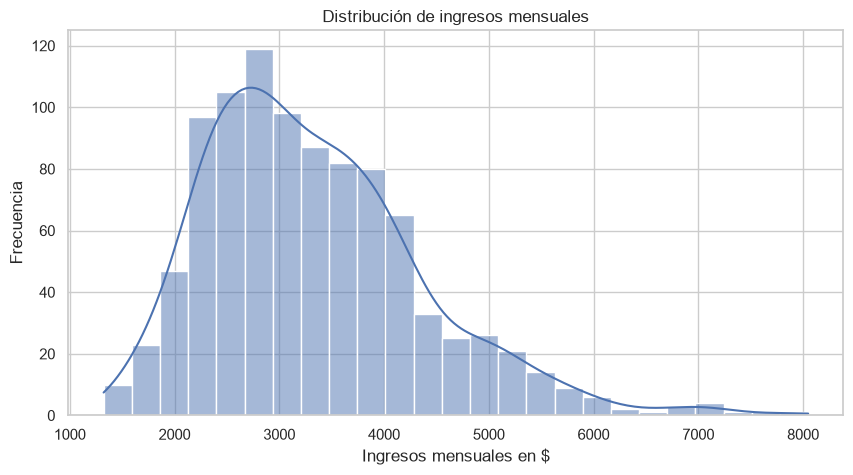

In [11]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df['monthly_sales'],
    kde=True
)

plt.title('Distribución de ingresos mensuales')
plt.xlabel('Ingresos mensuales en $')
plt.ylabel('Frecuencia')

plt.show()

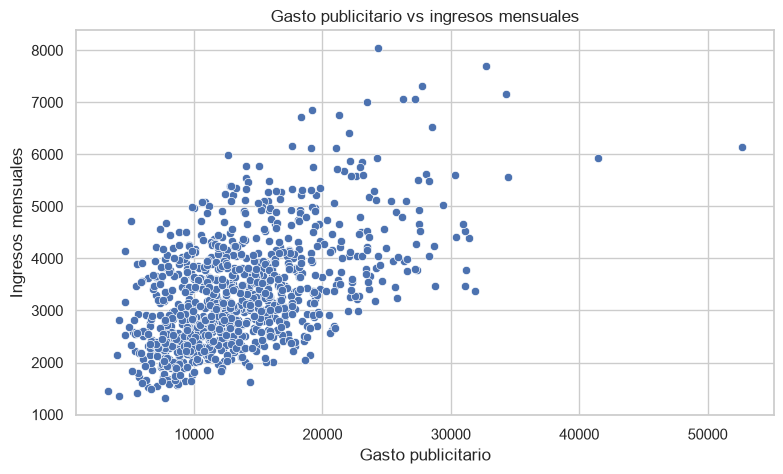

In [12]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x='ad_spend',
    y='monthly_sales'
)

plt.title('Gasto publicitario vs ingresos mensuales')
plt.xlabel('Gasto publicitario')
plt.ylabel('Ingresos mensuales')

plt.show()

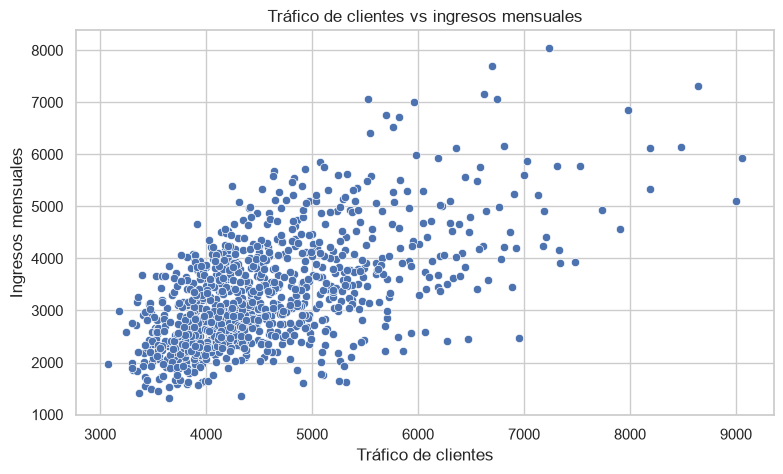

In [13]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x='foot_traffic',
    y='monthly_sales'
)

plt.title('Tráfico de clientes vs ingresos mensuales')
plt.xlabel('Tráfico de clientes')
plt.ylabel('Ingresos mensuales')

plt.show()

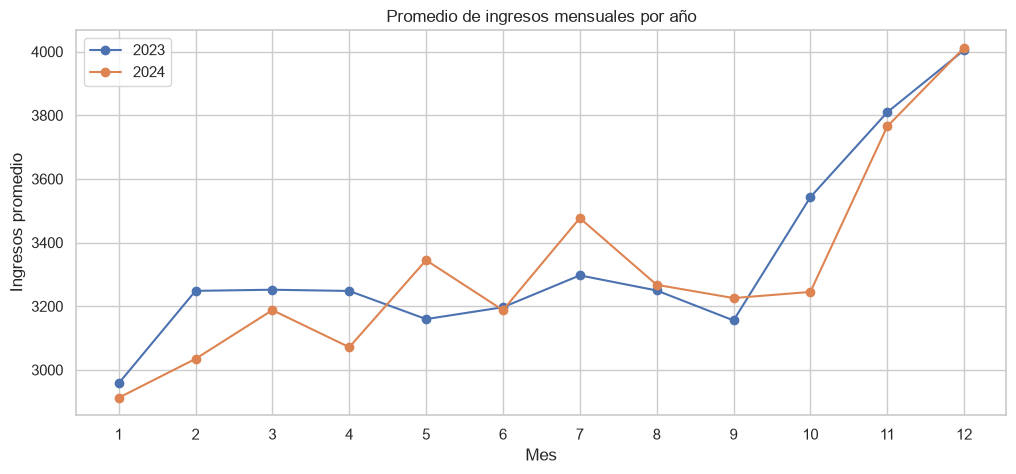

In [14]:
ventas_mensuales = (
    df.groupby(['year', 'month'])['monthly_sales']
      .mean()
      .reset_index()
)

plt.figure(figsize=(12, 5))

for year in ventas_mensuales['year'].unique():

    datos = ventas_mensuales[
        ventas_mensuales['year'] == year
    ]

    plt.plot(
        datos['month'],
        datos['monthly_sales'],
        marker='o',
        label=str(year)
    )

plt.title('Promedio de ingresos mensuales por año')
plt.xlabel('Mes')
plt.ylabel('Ingresos promedio')
plt.xticks(range(1, 13))
plt.legend()

plt.show()

### 3.4 Correlacion

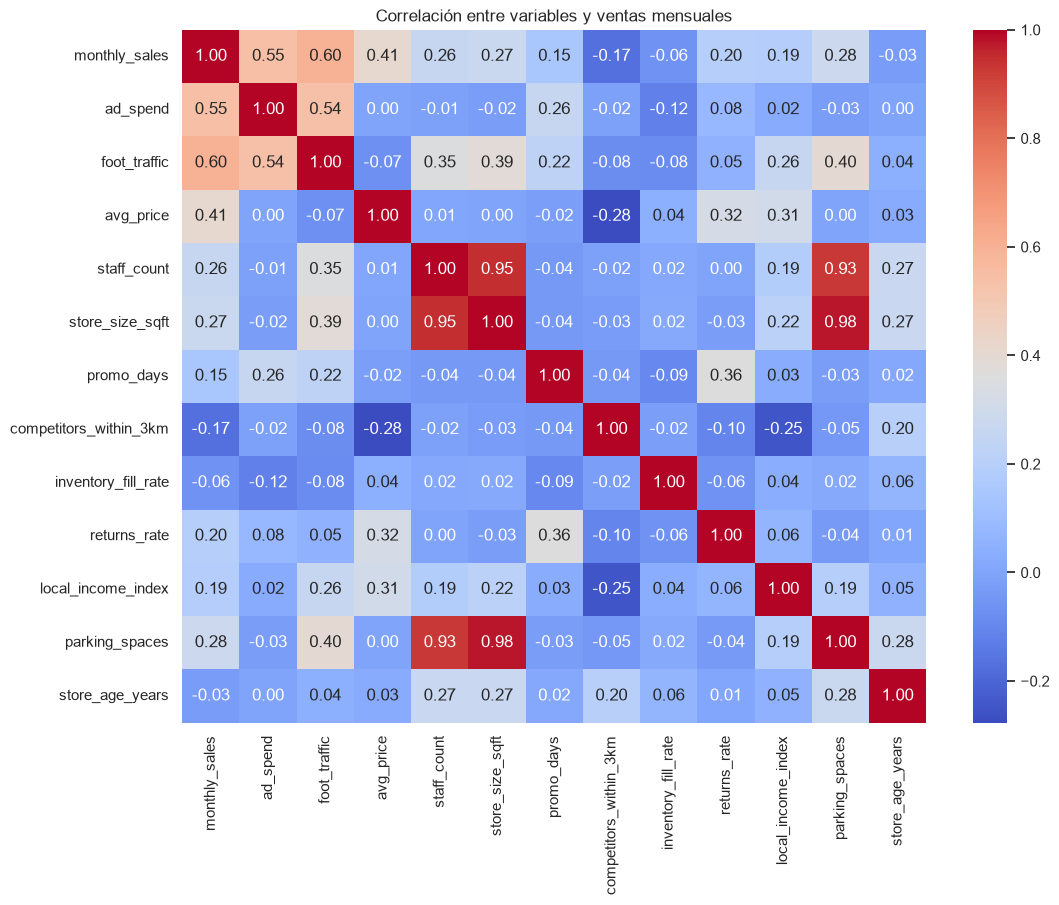

In [15]:
variables_corr = [
    'monthly_sales',
    'ad_spend',
    'foot_traffic',
    'avg_price',
    'staff_count',
    'store_size_sqft',
    'promo_days',
    'competitors_within_3km',
    'inventory_fill_rate',
    'returns_rate',
    'local_income_index',
    'parking_spaces',
    'store_age_years'
]

corr = df[variables_corr].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlación entre variables y ventas mensuales')
plt.show()

## 4. Implementación y comparación de modelos

## 5. Análisis de límites y riesgos

## 6. Consideraciones éticas

## 7. Conclusión y recomendación final